In [6]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import signal
import sys

# Globale Einstellungen für schönere Zahlen-Ausgabe (wie im vorigen Skript)
np.set_printoptions(formatter={'float_kind': lambda x: "{: .4f}".format(x)})

In [3]:
# Übertragungsfunktion H(z) = B(z) / A(z)
# Koeffizienten definieren
B = np.array([0.862, -1.219, 0.862])
A = np.array([1.0, -1.134, 0.604])

## a) Stabilität prüfen (Pole berechnen)

In [4]:
# In Python heißt der Befehl auch roots() (in numpy)
x12 = np.roots(A)

print("Pole (x12):")
print(x12)

print("Betrag der Pole:")
abs_x12 = np.abs(x12)
print(abs_x12)

# Überprüfung auf Stabilität
if np.any(abs_x12 > 1):
    print("System ist instabil")
else:
    print("System ist stabil")

Pole (x12):
[0.567+0.53151764j 0.567-0.53151764j]
Betrag der Pole:
[ 0.7772  0.7772]
System ist stabil


## b) Pol-Nullstellen-Plan (zplane Ersatz)

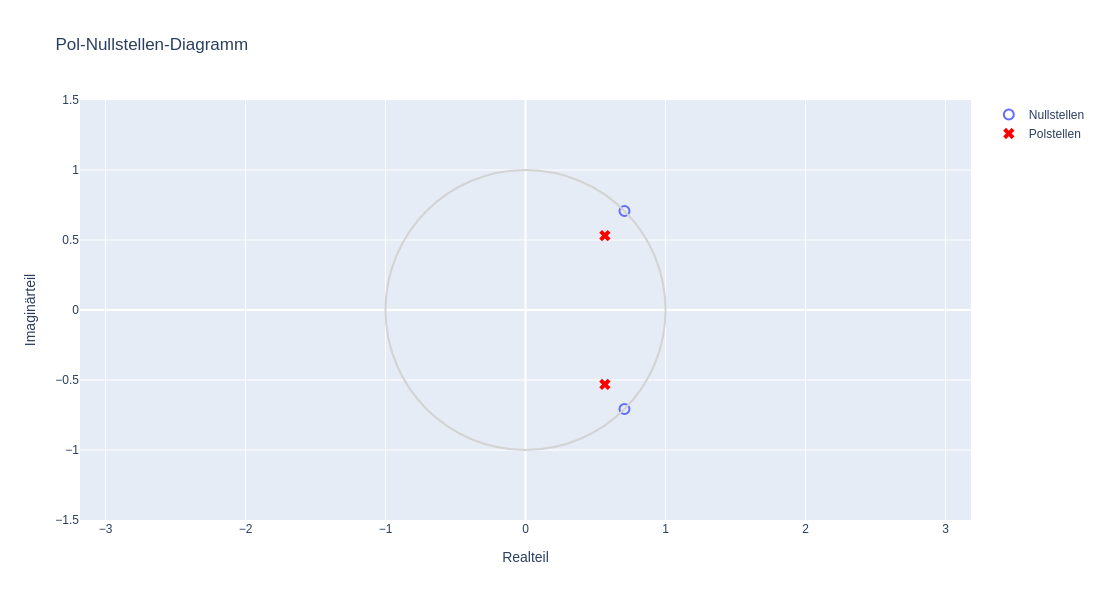

In [35]:
# Python hat kein natives 'zplane', wir bauen es mit Matplotlib

fvPoles = np.roots(A)
fvZeros = np.roots(B)

# Figure erstellen
fig_zplane = go.Figure()

# 1. Einheitskreis hinzufügen
fig_zplane.add_shape(
    type="circle",
    xref="x", yref="y",
    x0=-1, y0=-1, x1=1, y1=1,
    line_color="LightGrey",
)

# 2. Nullstellen (Zeros) als offene Kreise
fig_zplane.add_trace(
    go.Scatter(
        x=np.real(fvZeros), 
        y=np.imag(fvZeros),
        mode='markers',
        marker=dict(
            symbol='circle-open', 
            size=10, 
            line=dict(width=2, color='green')
        ),
        name='Nullstellen'
    )
)

# 3. Pole als X
fig_zplane.add_trace(
    go.Scatter(
        x=np.real(fvPoles),
        y=np.imag(fvPoles),
        mode='markers',
        marker=dict(symbol='x', size=10, color='red'),
        name='Polstellen'
    )
)

# Layout aufhübschen
fig_zplane.update_layout(
    title="Pol-Nullstellen-Diagramm",
    xaxis_title="Realteil",
    yaxis_title="Imaginärteil",
    width=800, 
    height=600,
    yaxis=dict(scaleanchor="x", scaleratio=1),
    xaxis=dict(range=[-1.5, 1.5]),
    yaxis_range=[-1.5, 1.5]
)
fig_zplane.show()

## c) Frequenzgang

Frequenz bei min(|H|): 0.7854 rad/sample


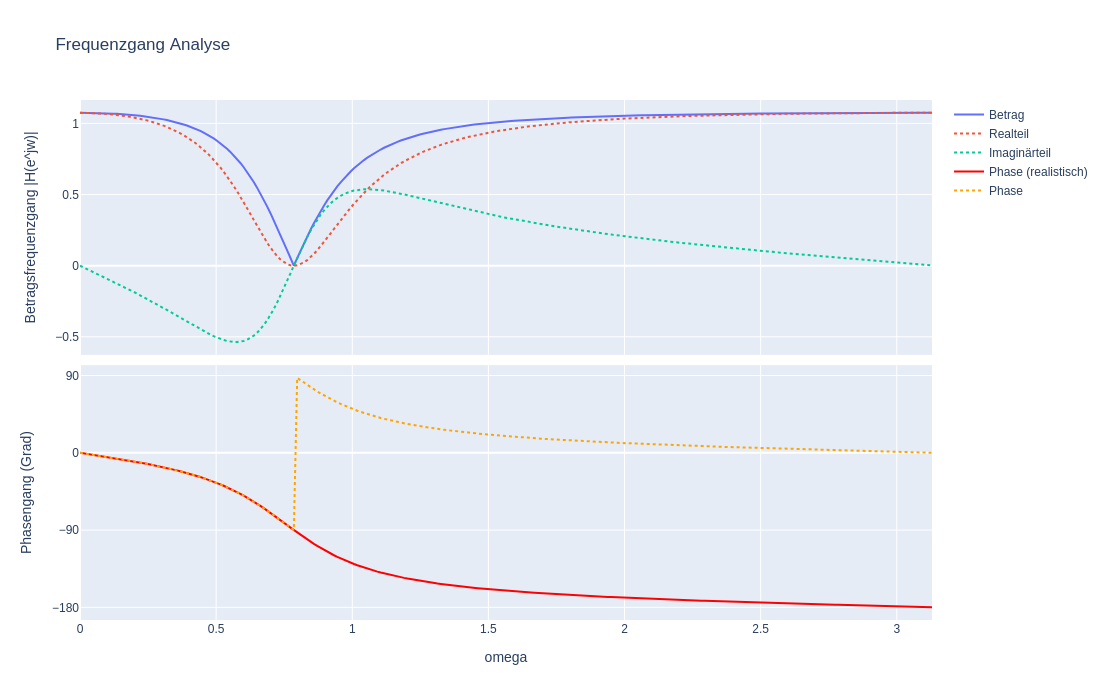

In [18]:
# freqz in Python:
# worN=256 entspricht der Anzahl der Punkte
# Rückgabe: w (Frequenzen in rad/sample), H (komplexer Frequenzgang)
w, H = signal.freqz(B, A, worN=256)

# Minimum des Betrags finden
abs_H = np.abs(H)
phase_deg = np.rad2deg(np.angle(H))
w_min_ind = np.argmin(abs_H)
print(f"Frequenz bei min(|H|): {w[w_min_ind]:.4f} rad/sample")

# Subplots erstellen (2 Zeilen)
fig_freq = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.02,
    # subplot_titles=("Betragsfrequenzgang |H(e^jw)|", "Phasengang (Grad)"),
)

# Betrag
fig_freq.add_trace(
    go.Scatter(
        x=w,
        y=np.abs(H),
        name='Betrag'
    ), row=1, col=1
)
fig_freq.add_trace(
    go.Scatter(
        x=w,
        y=np.real(H),
        name='Realteil',
        line=dict(dash='dot'),
    ), row=1, col=1
)
fig_freq.add_trace(
    go.Scatter(
        x=w,
        y=np.imag(H),
        name='Imaginärteil',
        line=dict(dash='dot'),
    ), row=1, col=1
)

# Phase
fig_freq.add_trace(
    go.Scatter(
        x=w,
        y=np.concat((phase_deg[:w_min_ind+1],phase_deg[w_min_ind+1:]-180)),
        name='Phase (realistisch)',
        line=dict(color='red')
    ), row=2, col=1
)
fig_freq.add_trace(
    go.Scatter(
        x=w,
        y=phase_deg,
        name='Phase',
        line=dict(color='orange', dash='dot')
    ), row=2, col=1
)

fig_freq.update_layout(height=700, title_text="Frequenzgang Analyse", showlegend=True,)
fig_freq.update_xaxes(title_text="omega", row=2, col=1)
fig_freq.update_yaxes(tickmode="linear", tick0=-180, dtick=90, row=2, col=1)
fig_freq.for_each_xaxis(lambda x: x.update(showgrid=True))
fig_freq.update_yaxes(title_text="Betragsfrequenzgang |H(e^jw)|", row=1, col=1)
fig_freq.update_yaxes(title_text="Phasengang (Grad)", row=2, col=1)
fig_freq.show()

## d) Impuls- und Sprungantwort (Filterung)

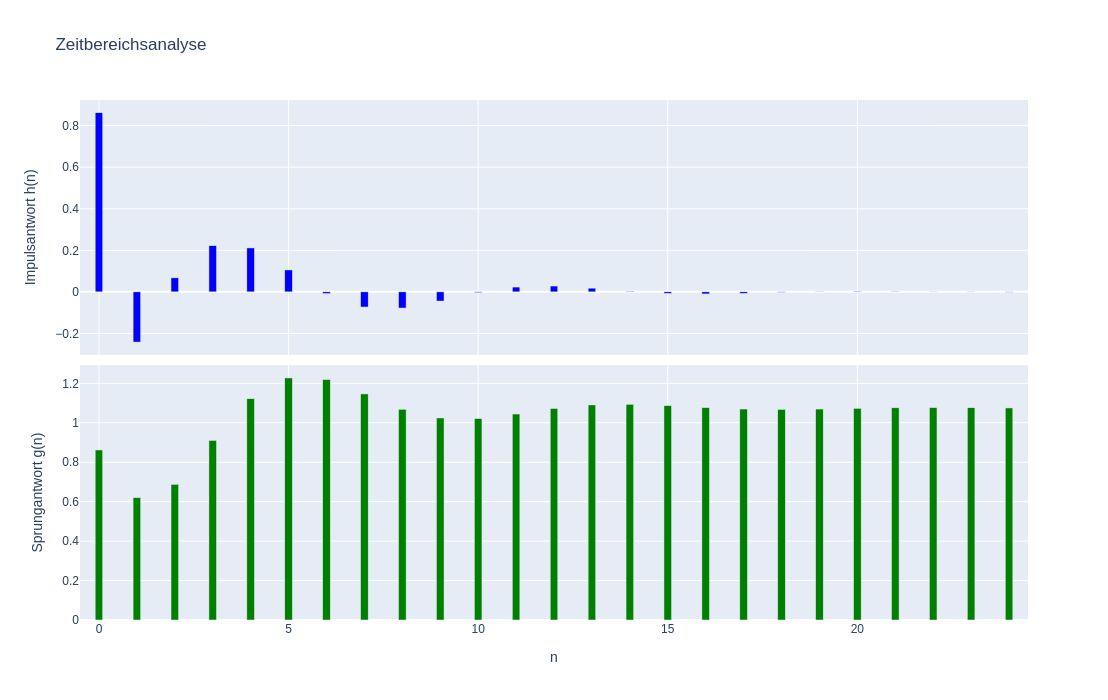

In [12]:
# Eingangssignale erstellen
N = 25
delta_inp = np.zeros(N); delta_inp[0] = 1
step_inp = np.ones(N)

h = signal.lfilter(B, A, delta_inp)
g = signal.lfilter(B, A, step_inp)
n_axis = np.arange(N)

# Funktion um "Stem"-Plot Look in Plotly zu erzeugen
# Wir nutzen Balken (Bar) mit sehr geringer Breite
def create_stem_trace(x, y, name, color):
    return go.Bar(
        x=x, y=y, 
        name=name,
        width=0.2, # Macht den Balken dünn -> sieht aus wie Stem
        marker_color=color
    )

fig_time = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.02,
    # subplot_titles=("Impulsantwort h(n)", "Sprungantwort g(n)")
)

# Impulsantwort
fig_time.add_trace(create_stem_trace(n_axis, h, "h(n)", "blue"), row=1, col=1)

# Sprungantwort
fig_time.add_trace(create_stem_trace(n_axis, g, "g(n)", "green"), row=2, col=1)

fig_time.update_layout(height=700, title_text="Zeitbereichsanalyse", showlegend=False)
fig_time.update_xaxes(title_text="n", row=2, col=1)
fig_time.for_each_xaxis(lambda x: x.update(showgrid=True))
fig_time.update_yaxes(title_text="Impulsantwort h(n)", row=1, col=1)
fig_time.update_yaxes(title_text="Sprungantwort g(n)", row=2, col=1)
fig_time.show()

## Alternativ 2024 (Systemtheorie Ansatz)

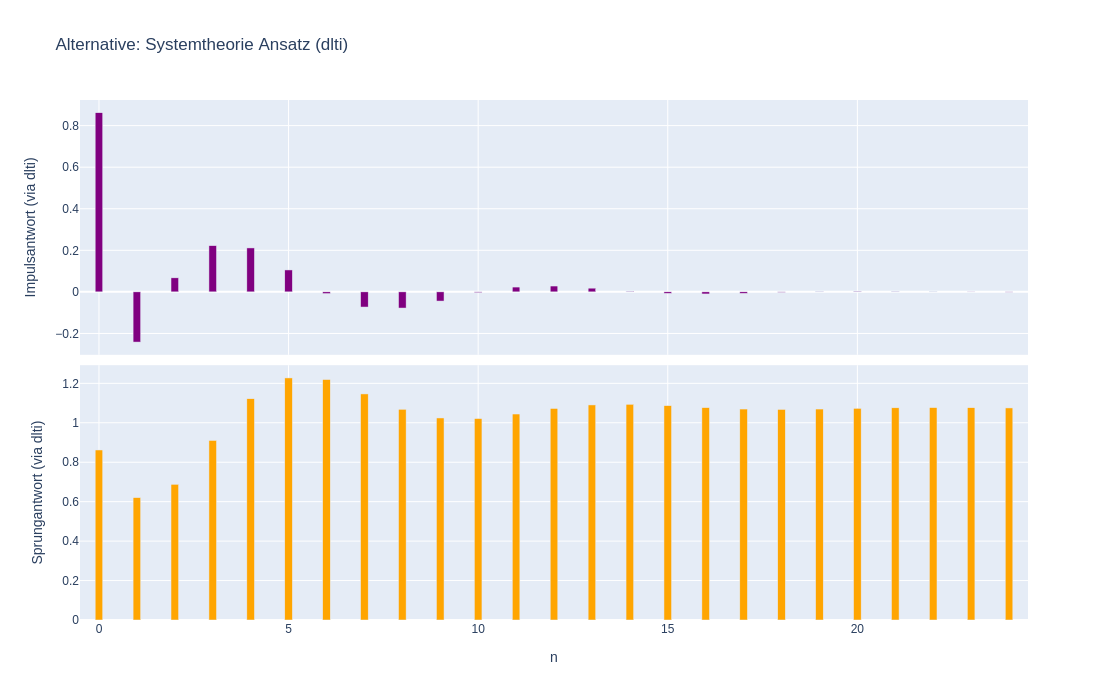

In [19]:
# In Python nutzen wir dafür scipy.signal.dlti (Discrete Linear Time Invariant)
# oder direkt dimpulse/dstep.

# System definieren mit Abtastzeit dt=1 (oder -1 für unbestimmt, hier nehmen wir 1 für Plots)
system = signal.dlti(B, A, dt=1)

# dimpulse und dstep berechnen
# n=N gibt an, wie viele Punkte berechnet werden sollen
t_imp, y_imp = signal.dimpulse(system, n=N)
t_step, y_step = signal.dstep(system, n=N)

# Da dimpulse oft eine Liste von Arrays zurückgibt (für MIMO Systeme),
# müssen wir bei SISO Systemen mit [0] das erste Element greifen (y_imp[0]).
y_imp = np.squeeze(y_imp)
y_step = np.squeeze(y_step)

fig_alt = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.02,
    # subplot_titles=("Impulsantwort (via dlti)", "Sprungantwort (via dlti)")
)

# Wir nutzen wieder den "Balken-Trick" für den Stem-Look
def create_stem(x, y, name, color):
    return go.Bar(
        x=x, y=y, 
        name=name, 
        width=0.2,          # Dünne Balken = Stem-Optik
        marker_color=color
    )

# Subplot 1: Impulsantwort
fig_alt.add_trace(
    create_stem(t_imp, y_imp, "h(n)", "purple"), 
    row=1, col=1
)

# Subplot 2: Sprungantwort
fig_alt.add_trace(
    create_stem(t_step, y_step, "g(n)", "orange"), 
    row=2, col=1
)

# Layout finalisieren
fig_alt.update_layout(
    height=700, 
    title_text="Alternative: Systemtheorie Ansatz (dlti)", 
    showlegend=False
)
fig_alt.update_xaxes(title_text="n", row=2, col=1)
fig_alt.update_yaxes(title_text="Impulsantwort (via dlti)", row=1, col=1)
fig_alt.update_yaxes(title_text="Sprungantwort (via dlti)", row=2, col=1)
fig_alt.for_each_xaxis(lambda x: x.update(showgrid=True))

fig_alt.show()

## LCApy (experimentell)

--- Start MA4 (Lcapy Version Fixed) ---

--- Teil a) Stabilität ---
(431/500 - 1219/(1000*z) + 431/(500*z**2))/(1 - 567/(500*z) + 151/(250*z**2))
-> System ist stabil

--- Teil b) Pol-Nullstellen-Plan ---

--- Teil c) Frequenzgang ---

--- Teil d) Zeitbereich ---


<Figure size 640x480 with 0 Axes>

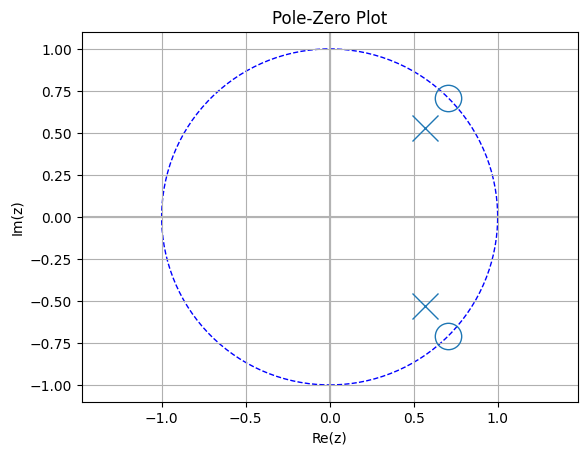

<Figure size 640x480 with 0 Axes>

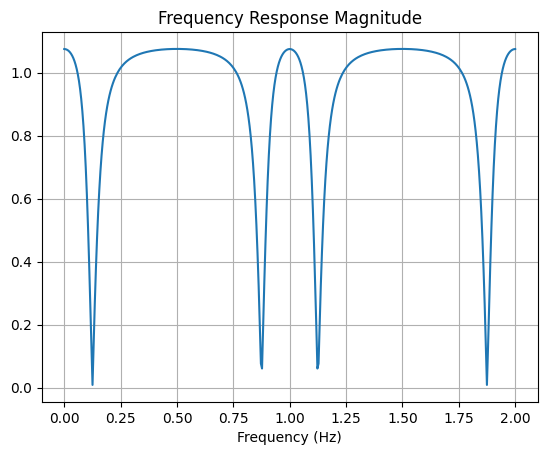

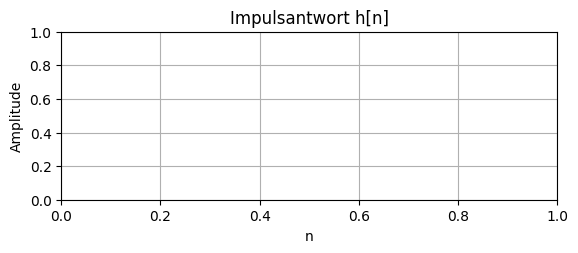

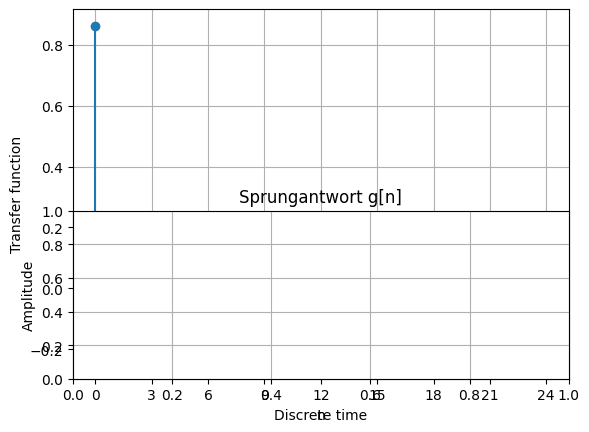

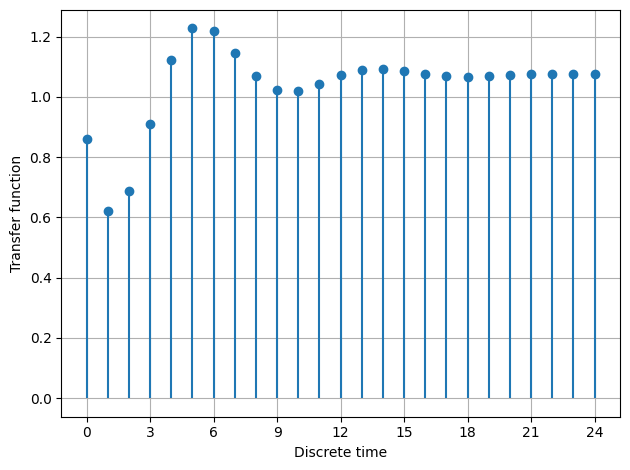

In [26]:
from lcapy import DLTIFilter
from matplotlib.pyplot import show, figure, subplot
import matplotlib.pyplot as plt

print("--- Start MA4 (Lcapy Version Fixed) ---")

B_coeffs = [0.862, -1.219, 0.862]
A_coeffs = [1.0, -1.134, 0.604]

# Filter erstellen (ohne dt)
H = DLTIFilter(B_coeffs, A_coeffs)

# %% a) Stabilität
print("\n--- Teil a) Stabilität ---")
print(H.transfer_function())
if H.is_stable:
    print("-> System ist stabil")
else:
    print("-> System ist instabil")

# %% b) Pol-Nullstellen
print("\n--- Teil b) Pol-Nullstellen-Plan ---")
figure()
H.transfer_function().plot(title="Pole-Zero Plot")

# %% c) Frequenzgang
print("\n--- Teil c) Frequenzgang ---")
figure()
# Hier nutzen wir den vorherigen Fix: .magnitude für linearen Plot
H.frequency_response().subs('Delta_t', 1).magnitude.plot(title="Frequency Response Magnitude")

# %% d) Zeitbereich (HIER IST DER FIX)
print("\n--- Teil d) Zeitbereich ---")

# 1. Formeln holen
h_expr = H.impulse_response()
g_expr = H.step_response()

figure()

# --- Subplot 1: Impulsantwort ---
ax1 = subplot(211)

# WICHTIG: Wir setzen ax1 als "aktive" Achse, statt es zu übergeben.
# Das umgeht den "multiple values for argument ax" Fehler.
plt.sca(ax1) 

# Plotten ohne Argumente (außer dem Bereich)
h_expr.plot((0, 24)) 

# Titel und Labels manuell setzen (sicherer)
ax1.set_title("Impulsantwort h[n]")
ax1.set_xlabel("n")
ax1.set_ylabel("Amplitude")
ax1.grid(True)


# --- Subplot 2: Sprungantwort ---
ax2 = subplot(212)

# Achse aktivieren
plt.sca(ax2)

# Plotten
g_expr.plot((0, 24))

# Titel und Labels
ax2.set_title("Sprungantwort g[n]")
ax2.set_xlabel("n")
ax2.set_ylabel("Amplitude")
ax2.grid(True)

# Layout optimieren und zeigen
plt.tight_layout()
show()